         

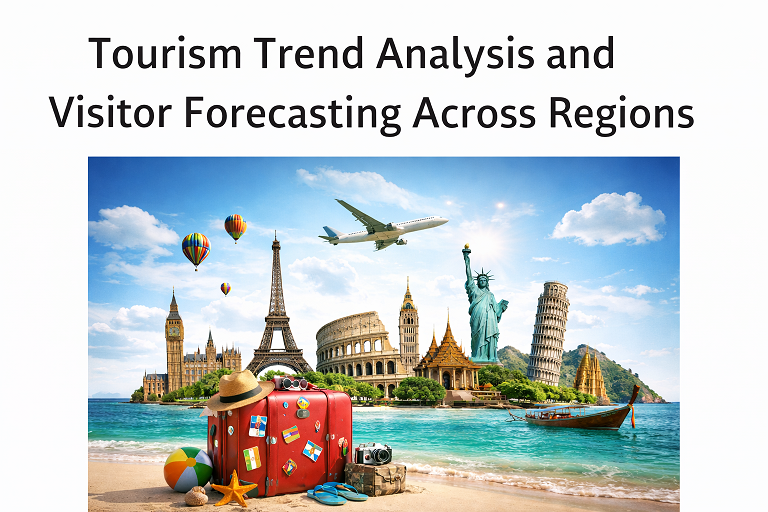

<div style="background-color:#f4f6f7; padding:14px; border-left:6px solid #2e86c1; border-radius:6px;">
<h2 style="color:#2e86c1; font-size:20px; font-weight:bold; font-family:Arial, sans-serif; margin:0;">
 PROJECT OBJECTIVE
</h2>
<p style="font-size:14px; margin-top:8px;">
The objective of this project is to analyze tourism trends across different regions and time periods to understand patterns in visitor behavior, seasonal variations, and tourism revenue. The project also aims to forecast future visitor numbers using data analysis and predictive techniques to support better tourism planning and management.
</p>
</div>

<div style="text-align:center;">
<h2 style="color:#2e86c1; font-family:Arial, sans-serif; font-size:24px; font-weight:bold;">
STEP 1.DATA LOADING AND INITIAL OVERVIEW
</h2>
</div>In this section, the tourism dataset is imported using the Pandas library. An initial exploration is performed to understand the structure of the dataset, including the number of rows and columns, data types, and basic statistical information.

In [2]:
# 1.1 Import Dataset using Pandas

import pandas as pd
import numpy as np

In [3]:
# 1.2 Load dataset

df = pd.read_csv("tourism dataset.csv")

In [4]:
# 1.3 Number of Rows and columns

import pandas as pd
import numpy as np

df = pd.read_csv("tourism dataset.csv")
df.shape

(12000, 11)

So the dataset contains 12,000(row) tourism visit records with 11 Columns.

In [5]:
# 1.4 Data Types of Each Column
 
df.dtypes

Visit_ID              object
Tourist_Origin        object
Destination _City     object
Destination_Type      object
Visitor_Type          object
Season                object
Visit_Date            object
Visitors_Count       float64
Average_Rating       float64
Revenue_USD          float64
Average_Spending     float64
dtype: object

## Findings:

* The dataset includes categorical columns: Tourist_Origin, Destination_City, Destination_Type, Visitor_Type, and      Season
* Numerical columns include: Visitors_Count, Average_Rating, Revenue_USD, and Average_Spending
* A date column (Visit_Date) is present for time-based analysis
* Visit_ID serves as a unique identifier for each record
* Average_Spending is calculated as Revenue ÷ Visitors_Count
* The dataset is suitable for GroupBy operations, pivot tables, and correlation analysis

In [6]:
# 1.5 First Few Rows of Dataset

df.head(10)


,Visit_ID,Tourist_Origin,Destination _City,Destination_Type,Visitor_Type,Season,Visit_Date,Visitors_Count,Average_Rating,Revenue_USD,Average_Spending
0,VIS1,France,Dubai,Hill Station,Domestic,Monsoon,8/17/2021,214.0,3.98,48713.71,227.634159
1,VIS2,France,Kuala Lumpur,Wildlife,Domestic,Monsoon,3/7/2021,254.0,3.86,11743.61,46.234685
2,VIS3,Dubai,India,City Tourism,International,Summer,3/28/2022,3689.0,4.41,682444.31,184.994391
3,VIS4,Malaysia,Rome,Wildlife,International,Winter,7/29/2021,769.0,4.93,97185.95,126.379649
4,VIS5,Malaysia,Singapore,Hill Station,Domestic,Winter,2/15/2023,655.0,4.96,114344.25,174.571374
5,VIS6,Indonesia,Rome,Hill Station,International,Summer,4/22/2022,837.0,4.84,105826.38,126.435340
6,VIS7,Singapore,Kerala,Adventure,International,Summer,5/27/2021,5000.0,3.89,988969.60,197.793920
7,VIS8,India,Rome,Adventure,International,Winter,10/27/2022,468.0,4.69,39374.46,84.133462
8,VIS9,Singapore,Bali,Hill Station,International,Winter,10/7/2022,1751.0,3.16,356368.47,203.522827
9,VIS10,Singapore,Rome,Hill Station,Domestic,Monsoon,4/12/2024,3519.0,4.65,955022.84,271.390406


## Findings:

* The dataset contains tourism visits from different countries
* It includes details such as visitor type, destination, season, ratings, and revenue
* Both domestic and international tourists are covered
* Various destination types are included in the dataset
* It contains visitor counts, revenue, average ratings, and spending data
* The dataset is useful for analyzing trends, revenue patterns, and tourist behavior

In [7]:
# 1.6 Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Visit_ID           12000 non-null  object 
 1   Tourist_Origin     12000 non-null  object 
 2   Destination _City  11999 non-null  object 
 3   Destination_Type   11991 non-null  object 
 4   Visitor_Type       11999 non-null  object 
 5   Season             11995 non-null  object 
 6   Visit_Date         11877 non-null  object 
 7   Visitors_Count     11751 non-null  float64
 8   Average_Rating     12000 non-null  float64
 9   Revenue_USD        11997 non-null  float64
 10  Average_Spending   12000 non-null  float64
dtypes: float64(4), object(7)
memory usage: 1.0+ MB


## Findings:

* The dataset is well-structured and organized
* It contains some missing values
* Data cleaning is required before analysis
* Type conversion may be needed for certain columns
* The dataset is suitable for tourism trend analysis
* It can be effectively used for revenue analysis

In [8]:
# 1.7 Column Names

print(df.columns)

Index(['Visit_ID', 'Tourist_Origin', 'Destination _City', 'Destination_Type',
       'Visitor_Type', 'Season', 'Visit_Date', 'Visitors_Count',
       'Average_Rating', 'Revenue_USD', 'Average_Spending'],
      dtype='object')


## Findings:

* The dataset contains 11 columns with both categorical and numerical features
* It includes Visit_ID as a unique identifier
* Categorical data includes tourist origin, destination, visitor type, and season
* A visit date column is available for time-based analysis
* Numerical features include visitor count, revenue, and average rating
* Average spending is a derived column
* The dataset is useful for analyzing tourism patterns, trends, and spending behavior


In [10]:
# 1.8 Statistical Summary

df.describe()

,Visitors_Count,Average_Rating,Revenue_USD,Average_Spending
count,11751.000000,12000.000000,1.199700e+04,12000.000000
mean,2501.133095,3.755979,4.004493e+05,156.409350
std,1437.364826,0.718756,3.294021e+05,83.499859
min,10.000000,2.500000,2.411900e+02,0.000000
25%,1260.000000,3.140000,1.299335e+05,84.357109
50%,2474.000000,3.770000,3.084245e+05,156.349074
75%,3749.000000,4.370000,6.017618e+05,228.588421
max,5000.000000,5.000000,1.480022e+06,299.987173


## Findings:

* Visitors_Count has 11,751 valid entries with some missing values
* The average number of visitors is 2,501, ranging from 10 to 5,000
* The average rating is 3.75, with a range of 2.5 to 5.0
* The average revenue is 400,449 USD, ranging from 241 to 1.48 million USD
* The average spending is 156 USD, with a range of 0 to 300 USD


<div style="background-color:#eff6ff; padding:12px; border-left:6px solid #3b82f6; border-radius:6px;">
<h2 style="color:#1e3a8a; font-size:20px; margin:0; font-weight:bold;">
INITIAL OBSERVATIONS
</h2>
</div>

* The dataset has 12,000 tourism records and 11 columns.
* Contains both categorical and numerical features.
* Some missing values exist, requiring data cleaning.
* Visit_Date is stored as object, which should be converted to datetime.
* Tourism revenue and visitor counts vary significantly, indicating good potential for 
  trend analysis and forecasting.